In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
import keras_nlp
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')

nltk.download('stopwords')

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

Libraries imported successfully!
TensorFlow version: 2.18.0


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [12]:
# List physical devices
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("🚀 GPU(s) detected!")
    for gpu in gpus:
        print(f" - {gpu}")
    print("TensorFlow will use the GPU by default when available.")
else:
    print("⚠️ No GPU detected. Using CPU only.")

🚀 GPU(s) detected!
 - PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
TensorFlow will use the GPU by default when available.


In [13]:
# Load the dataset
df = pd.read_csv('clean_song_list_10000.csv')

# Display basic info about the dataset
print("Dataset shape:", df.shape)
print("\nDataset info:")
print(df.info())
print("\nGenre distribution:")
print(df['tag'].value_counts())
print("\nFirst few rows:")
print(df.head())

Dataset shape: (28705, 5)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28705 entries, 0 to 28704
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  28705 non-null  int64 
 1   title       28704 non-null  object
 2   tag         28705 non-null  object
 3   artist      28705 non-null  object
 4   lyrics      28705 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.1+ MB
None

Genre distribution:
tag
rock    10000
rb      10000
rap      8705
Name: count, dtype: int64

First few rows:
   Unnamed: 0                               title   tag         artist  \
0           0                    Goons of Hazzard  rock  Dead Kennedys   
1           1  Summertime Blues Royal Albert Hall  rock        The Who   
2           2         I Call My Pain by Your Name  rock    Ellen Foley   
3           3           And the Healing Has Begun  rock   Van Morrison   
4           4                       

In [14]:
# Text preprocessing function
def preprocess_text(text):
    """
    Preprocess text data for LSTM model
    """
    if pd.isna(text):
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token not in stop_words]

    return ' '.join(tokens)

# Apply preprocessing
print("Preprocessing lyrics...")
df['processed_lyrics'] = df['lyrics'].apply(preprocess_text)

# Remove rows with empty processed lyrics
df = df[df['processed_lyrics'].str.len() > 0]
print(f"Dataset shape after preprocessing: {df.shape}")

Preprocessing lyrics...
Dataset shape after preprocessing: (28705, 6)


In [15]:
# Prepare features and labels
X = df['processed_lyrics'].values
y = df['tag'].values

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Get number of classes
num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Number of classes: 3
Classes: ['rap' 'rb' 'rock']
Training set size: 22964
Test set size: 5741


In [19]:
# --- 1. Prepare features and labels ---
X = df['lyrics'].values
y = df['tag'].values

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# --- 2. Create TensorFlow Datasets ---
# This creates datasets that stream data from memory, preventing OOM errors.
BATCH_SIZE = 8 # Set the batch size here

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("✅ tf.data.Dataset pipelines created successfully.")

# --- 3. Build a Custom Model with Added Regularization ---
preprocessor = keras_nlp.models.DistilBertPreprocessor.from_preset(
    "distil_bert_base_en_uncased",
    sequence_length=256
)
backbone = keras_nlp.models.DistilBertBackbone.from_preset(
    "distil_bert_base_en_uncased"
)

# Define the model architecture using Keras functional API
# This avoids passing the entire dataset through the preprocessor at once.
inputs = tf.keras.Input(shape=(), dtype=tf.string)

# The preprocessor is now the first layer of the model.
preprocessed_inputs = preprocessor(inputs)
sequence_output = backbone(preprocessed_inputs)

pooled_output = tf.keras.layers.GlobalAveragePooling1D()(sequence_output)
regularized_output = tf.keras.layers.Dropout(0.5)(pooled_output)
outputs = tf.keras.layers.Dense(num_classes, activation=None)(regularized_output)

classifier = tf.keras.Model(inputs=inputs, outputs=outputs)

# --- 4. Compile with a Lower Learning Rate and Scheduler ---
total_steps = len(train_dataset) * 5 # (steps_per_epoch) * epochs
warmup_steps = int(0.1 * total_steps)
lr_schedule = tf.keras.optimizers.schedules.PolynomialDecay(
    initial_learning_rate=2e-5,
    decay_steps=total_steps - warmup_steps,
    end_learning_rate=0.0,
)

classifier.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    metrics=["accuracy"],
    jit_compile=False
)

classifier.summary()

✅ tf.data.Dataset pipelines created successfully.


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distil_bert_text_c… │ [(None, 256),     │          0 │ input_layer_2[0]… │
│ (DistilBertTextCla… │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distil_bert_backbo… │ (None, 256, 768)  │ 66,362,880 │ distil_bert_text… │
│ (DistilBertBackbon… │                   │            │ distil_bert_text… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 768)       │          0 │ distil_bert_back… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 768)       │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │      2,307 │ dropout_25[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 66,365,187 (253.16 MB)

 Trainable params: 66,365,187 (253.16 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# --- 4. Define Callbacks ---
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3, # Can be more aggressive with BERT
    restore_best_weights=True,
    verbose=1
)

# --- 5. Train the Model ---
# Pass the tf.data.Dataset objects directly to the fit method.
print("Fine-tuning the BERT model with KerasNLP...")
history = classifier.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=5,
    callbacks=[early_stopping]
)

print("\nTraining completed!")

Fine-tuning the BERT model with KerasNLP...
Epoch 1/5
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 846s 287ms/step - accuracy: 0.7074 - loss: 0.6685 - val_accuracy: 0.7746 - val_loss: 0.5387
Epoch 2/5
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 818s 285ms/step - accuracy: 0.8093 - loss: 0.4697 - val_accuracy: 0.7955 - val_loss: 0.4990
Epoch 3/5
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 818s 285ms/step - accuracy: 0.8701 - loss: 0.3388 - val_accuracy: 0.7922 - val_loss: 0.5490
Epoch 4/5
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 819s 285ms/step - accuracy: 0.9209 - loss: 0.2173 - val_accuracy: 0.7767 - val_loss: 0.6962
Epoch 5/5
2871/2871 ━━━━━━━━━━━━━━━━━━━━ 819s 285ms/step - accuracy: 0.9522 - loss: 0.1349 - val_accuracy: 0.7810 - val_loss: 0.7795
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

Training completed!


Evaluating the model on the test set...
718/718 ━━━━━━━━━━━━━━━━━━━━ 55s 76ms/step - accuracy: 0.8018 - loss: 0.4833

Test Accuracy: 0.7955
Test Loss: 0.4990

Making predictions on the test set...
718/718 ━━━━━━━━━━━━━━━━━━━━ 57s 77ms/step

Classification Report:
              precision    recall  f1-score   support

         rap       0.81      0.83      0.82      1741
          rb       0.73      0.75      0.74      2000
        rock       0.85      0.81      0.83      2000

    accuracy                           0.80      5741
   macro avg       0.80      0.80      0.80      5741
weighted avg       0.80      0.80      0.80      5741



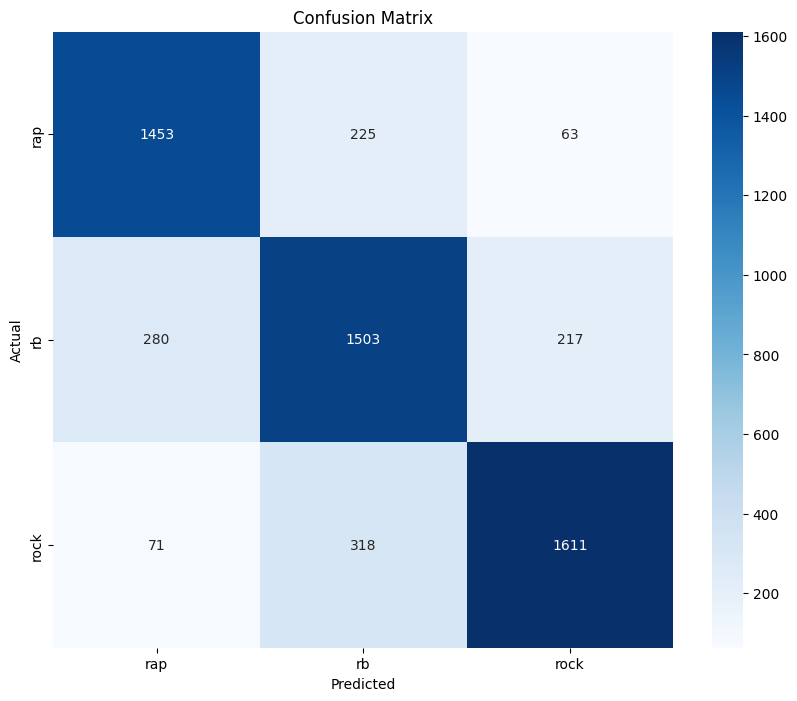

In [21]:
# Evaluate the model
print("Evaluating the model on the test set...")
test_loss, test_accuracy = classifier.evaluate(test_dataset, verbose=1)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Make predictions
print("\nMaking predictions on the test set...")
y_pred_logits = classifier.predict(test_dataset)
y_pred_classes = np.argmax(y_pred_logits, axis=1)

# Get the true labels by extracting them from the test_dataset
y_true_classes = np.concatenate([y for x, y in test_dataset], axis=0)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes,
                          target_names=label_encoder.classes_))

# Confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true_classes, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

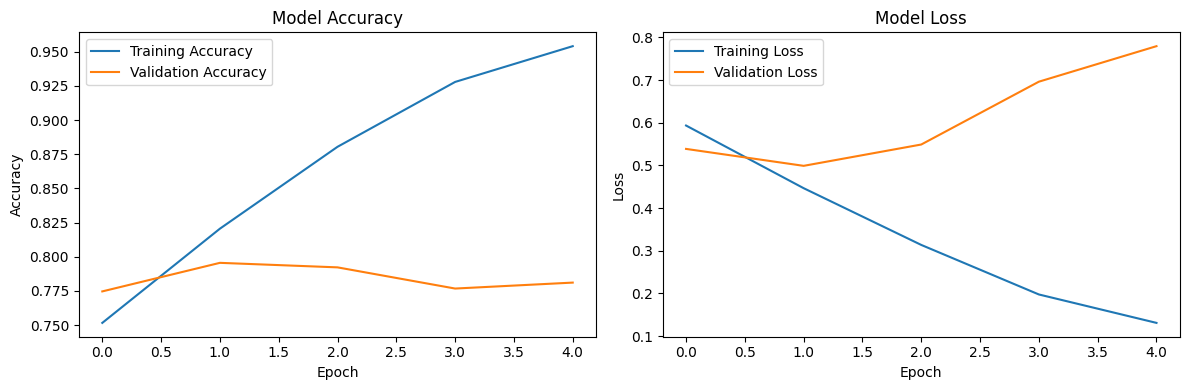

In [22]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()